<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_II_Classical_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torch-geometric numpy matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.4 MB/s eta 0:00:00


In [2]:
!wget https://zenodo.org/record/3164691/files/QG_jets.npz

--2026-03-26 17:20:29--  https://zenodo.org/record/3164691/files/QG_jets.npz
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.153.219, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/3164691/files/QG_jets.npz [following]
--2026-03-26 17:20:29--  https://zenodo.org/records/3164691/files/QG_jets.npz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 106689379 (102M) [application/octet-stream]
Saving to: ‘QG_jets.npz’

QG_jets.npz         100%[===================>] 101.75M  21.3MB/s    in 6.1s    

2026-03-26 17:20:36 (16.6 MB/s) - ‘QG_jets.npz’ saved [106689379/106689379]



In [3]:
import numpy as np
data = np.load('QG_jets.npz', allow_pickle=True)

X = data['X']
y = data['y']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Sample label:", y[0])
print("Sample features:", X[0][0])

Shape of X: (100000, 139, 4)
Shape of y: (100000,)
Sample label: 1.0
Sample features: [ 0.26876914  0.35690317  4.74138734 22.        ]


In [4]:
import torch
from torch_geometric.data import Data

def jet_to_graph(jet_features, label, k=5):
    mask = jet_features[:, 0] > 0
    features = jet_features[mask]
    x = torch.tensor(features, dtype=torch.float)
    num_particles = len(features)
    edge_index = []

    for i in range(num_particles):
        distances = []
        for j in range(num_particles):
            if i != j:
                deta = features[i][1] - features[j][1]
                dphi = features[i][2] - features[j][2]
                dist = deta**2 + dphi**2
                distances.append((dist, j))
        distances.sort()
        for _, j in distances[:k]:
            edge_index.append([i, j])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)
print("Converting jets to graphs...")
graph_list = []
for i in range(5000):
    graph_list.append(jet_to_graph(X[i], y[i]))
    if i % 500 == 0:
        print(f"  {i}/5000 done")

print("Done! Total graphs:", len(graph_list))

Converting jets to graphs...
  0/5000 done
  500/5000 done
  1000/5000 done
  1500/5000 done
  2000/5000 done
  2500/5000 done
  3000/5000 done
  3500/5000 done
  4000/5000 done
  4500/5000 done
Done! Total graphs: 5000


In [5]:
from torch_geometric.loader import DataLoader
train_data = graph_list[:4000]
test_data = graph_list[4000:]

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 4000
Test size: 1000


In [6]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GCN(nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(7, 64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 64)
        self.fc = nn.Linear(64, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x

print("GCN model ready!")

GCN model ready!


In [7]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(7, 64)
        self.conv2 = SAGEConv(64, 128)
        self.conv3 = SAGEConv(128, 64)
        self.fc = nn.Linear(64, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x

print("GraphSAGE model ready!")

GraphSAGE model ready!


In [8]:
sample = graph_list[0]
print("Number of features:", sample.x.shape[1])
print("Node feature shape:", sample.x.shape)

Number of features: 4
Node feature shape: torch.Size([18, 4])


In [9]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, global_mean_pool

num_features = graph_list[0].x.shape[1]
print("Using num_features:", num_features)

class GCN(nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, 128)
        self.conv3 = GCNConv(128, 64)
        self.fc = nn.Linear(64, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x

class GraphSAGE(nn.Module):
    def __init__(self):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, 64)
        self.conv2 = SAGEConv(64, 128)
        self.conv3 = SAGEConv(128, 64)
        self.fc = nn.Linear(64, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x

print("Models ready!")

Using num_features: 4
Models ready!


In [10]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_and_evaluate(model_class, name):
    model = model_class().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    print(f"\n--- Training {name} ---")
    for epoch in range(1, 21): # 20 epochs is a good baseline
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Evaluation
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                out = model(data)
                probs = F.softmax(out, dim=1)[:, 1] # Probability of class 1
                all_preds.extend(probs.cpu().numpy())
                all_labels.extend(data.y.cpu().numpy())

        auc = roc_auc_score(all_labels, all_preds)
        if epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | Loss: {total_loss/len(train_loader):.4f} | AUC: {auc:.4f}")
    return auc

gcn_auc = train_and_evaluate(GCN, "GCN")
sage_auc = train_and_evaluate(GraphSAGE, "GraphSAGE")


--- Training GCN ---
Epoch 05 | Loss: 0.6823 | AUC: 0.6677
Epoch 10 | Loss: 0.6169 | AUC: 0.6667
Epoch 15 | Loss: 0.5804 | AUC: 0.7537
Epoch 20 | Loss: 0.5552 | AUC: 0.7957

--- Training GraphSAGE ---
Epoch 05 | Loss: 0.5446 | AUC: 0.8016
Epoch 10 | Loss: 0.5038 | AUC: 0.8051
Epoch 15 | Loss: 0.4995 | AUC: 0.8201
Epoch 20 | Loss: 0.4919 | AUC: 0.8224


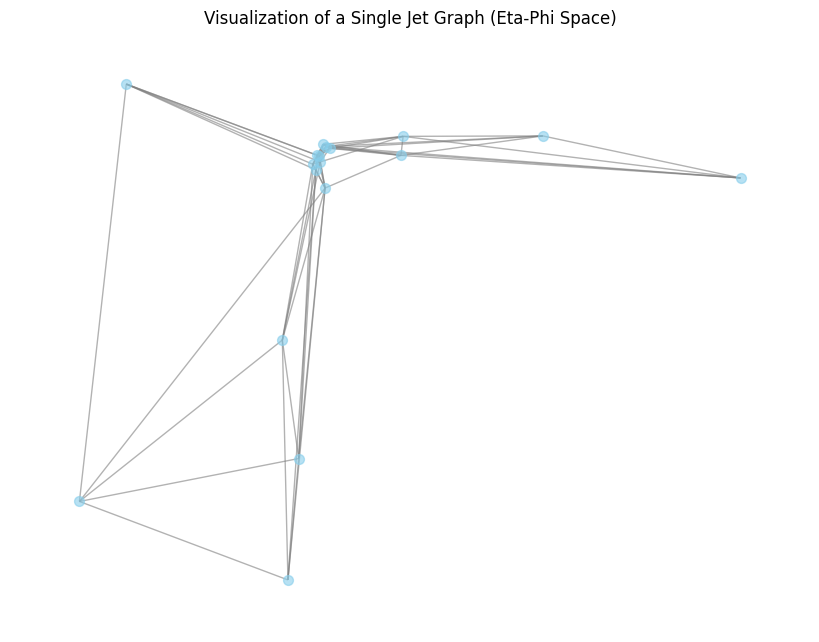

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_jet_graph(data):
    G = nx.Graph()
    # Add nodes with their pT as a size attribute
    for i in range(data.x.shape[0]):
        G.add_node(i, pos=(data.x[i, 1].item(), data.x[i, 2].item()))

    # Add edges
    edge_index = data.edge_index.numpy()
    for i in range(edge_index.shape[1]):
        G.add_edge(edge_index[0, i], edge_index[1, i])

    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, node_size=50, node_color='skyblue', edge_color='gray', alpha=0.6)
    plt.title("Visualization of a Single Jet Graph (Eta-Phi Space)")
    plt.xlabel("Eta")
    plt.ylabel("Phi")
    plt.show()

# Visualize the first jet in your dataset
visualize_jet_graph(graph_list[0])